In [123]:
import pandas as pd

stud = pd.read_csv('admission_data.csv')
stud

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,0.87,1
496,337,117,5,5.0,5.0,9.87,0.96,1
497,330,120,5,4.5,5.0,9.56,0.93,1
498,312,103,4,4.0,5.0,8.43,0.73,1


In [124]:
X = stud.drop(["Accept", "Chance of Admit"], axis=1).fillna(stud.mean())
y = stud["Accept"]

In [125]:
X.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA
0,337,118,4,4.5,4.5,9.65
1,324,107,4,4.0,4.5,8.87
2,316,104,3,3.0,3.5,8.00
3,322,110,3,3.5,2.5,8.67
4,314,103,2,2.0,3.0,8.21


In [126]:
y

0      1
1      1
2      1
3      1
4      0
      ..
495    1
496    1
497    1
498    1
499    1
Name: Accept, Length: 500, dtype: int64

In [127]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 23.6 KB


In [128]:
X.count

<bound method DataFrame.count of      GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA
0          337          118                  4  4.5  4.5  9.65
1          324          107                  4  4.0  4.5  8.87
2          316          104                  3  3.0  3.5  8.00
3          322          110                  3  3.5  2.5  8.67
4          314          103                  2  2.0  3.0  8.21
..         ...          ...                ...  ...  ...   ...
495        332          108                  5  4.5  4.0  9.02
496        337          117                  5  5.0  5.0  9.87
497        330          120                  5  4.5  5.0  9.56
498        312          103                  4  4.0  5.0  8.43
499        327          113                  4  4.5  4.5  9.04

[500 rows x 6 columns]>

In [129]:
y.count
y.value_counts()

Accept
1    300
0    200
Name: count, dtype: int64

### Student admission prediction

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

- Decision Tree

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model1 = DecisionTreeClassifier(max_depth=5)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Decision Tree: {acc}")

Accuracy of Decision Tree: 0.8


- Neural Network

In [132]:
from sklearn.neural_network import MLPClassifier

model2 = MLPClassifier(hidden_layer_sizes=(1000, 1000))

model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Neural Network: {acc}")

Accuracy of Neural Network: 0.72


### Decision tree rules

In [133]:
from sklearn.tree import export_text

rules = export_text(model1, feature_names=list(X_train.columns))

print(rules)

|--- CGPA <= 8.27
|   |--- TOEFL Score <= 103.50
|   |   |--- University Rating <= 4.50
|   |   |   |--- GRE Score <= 315.50
|   |   |   |   |--- class: 0
|   |   |   |--- GRE Score >  315.50
|   |   |   |   |--- SOP <= 1.75
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- SOP >  1.75
|   |   |   |   |   |--- class: 0
|   |   |--- University Rating >  4.50
|   |   |   |--- class: 1
|   |--- TOEFL Score >  103.50
|   |   |--- GRE Score <= 320.00
|   |   |   |--- GRE Score <= 309.50
|   |   |   |   |--- CGPA <= 8.11
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- CGPA >  8.11
|   |   |   |   |   |--- class: 0
|   |   |   |--- GRE Score >  309.50
|   |   |   |   |--- SOP <= 3.75
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SOP >  3.75
|   |   |   |   |   |--- class: 0
|   |   |--- GRE Score >  320.00
|   |   |   |--- class: 1
|--- CGPA >  8.27
|   |--- GRE Score <= 318.50
|   |   |--- GRE Score <= 306.50
|   |   |   |--- LOR <= 2.75
|   |   |   |   |--- TOEFL Score 

### Model-specific vs. model-agnostic techniques
| Model-specific | Model-agnostic|
|----------------|---------------|
|Apply to particular model | Apply to any model |

#### What's next?
- Model-specific and model-agnostic techniques
- Local and global methods
- Advanced topics:
    - Explainability metrics
    - Unsupervised explainability
    - Generative AI explainability

### Exercise:

In [134]:
adult = pd.read_csv('adult.csv')
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [135]:
X = pd.get_dummies(adult.drop('income', axis=1))
y = adult['income']

In [136]:
X.value_counts()


age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week  workclass_?  workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  workclass_Private  workclass_Self-emp-inc  workclass_Self-emp-not-inc  workclass_State-gov  workclass_Without-pay  education_10th  education_11th  education_12th  education_1st-4th  education_5th-6th  education_7th-8th  education_9th  education_Assoc-acdm  education_Assoc-voc  education_Bachelors  education_Doctorate  education_HS-grad  education_Masters  education_Preschool  education_Prof-school  education_Some-college  marital-status_Divorced  marital-status_Married-AF-spouse  marital-status_Married-civ-spouse  marital-status_Married-spouse-absent  marital-status_Never-married  marital-status_Separated  marital-status_Widowed  occupation_?  occupation_Adm-clerical  occupation_Armed-Forces  occupation_Craft-repair  occupation_Exec-managerial  occupation_Farming-fishing  occupation_Handlers-cleaners  occupation_Machine-op-inspct  oc

In [137]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Columns: 108 entries, age to native-country_Yugoslavia
dtypes: bool(102), int64(6)
memory usage: 7.0 MB


In [138]:
y.count

<bound method Series.count of 0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: income, Length: 48842, dtype: object>

In [139]:
y.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [141]:
model = DecisionTreeClassifier(random_state=42, max_depth=2)
model.fit(X_train, y_train)

# Extract the rules
rules = export_text(model, feature_names=list(X_train.columns))
print(rules)

y_pred = model.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital-gain <= 7073.50
|   |   |--- class: <=50K
|   |--- capital-gain >  7073.50
|   |   |--- class: >50K
|--- marital-status_Married-civ-spouse >  0.50
|   |--- educational-num <= 12.50
|   |   |--- class: <=50K
|   |--- educational-num >  12.50
|   |   |--- class: >50K

Accuracy: 0.83


In [142]:
model = MLPClassifier(hidden_layer_sizes=(36, 12), random_state=42)
# Train the MLPClassifier
model.fit(X_train, y_train)

# Derive the predictions on the test set
y_pred = model.predict(X_test)

# Compute the test accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82


In [143]:
# Standardize the training data

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
model = LinearRegression()

# Fit the model
model.fit(X_train_scaled, y_train)

# Derive coefficients
coefficients = model.coef_
feature_names = X_train.columns

# Plot coefficients
plt.bar(feature_names, coefficients)
plt.show()

NameError: name 'MinMaxScaler' is not defined

### Computing feature impact with logistic regression


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Derive coefficients
coefficients = model.coef_[0]
feature_names = X_train.columns

# Plot coefficients
plt.bar(feature_names, coefficients)
plt.show()

### EXplainability in tree-based models

In [150]:
import pandas as pd

stud = pd.read_csv('admission_data.csv')
stud

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,0.87,1
496,337,117,5,5.0,5.0,9.87,0.96,1
497,330,120,5,4.5,5.0,9.56,0.93,1
498,312,103,4,4.0,5.0,8.43,0.73,1


In [151]:
X_train = stud.drop(['Accept'], axis=1)
y_train = stud['Accept']

In [152]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

print(tree_model.feature_importances_)

[0. 0. 0. 0. 0. 0. 1.]


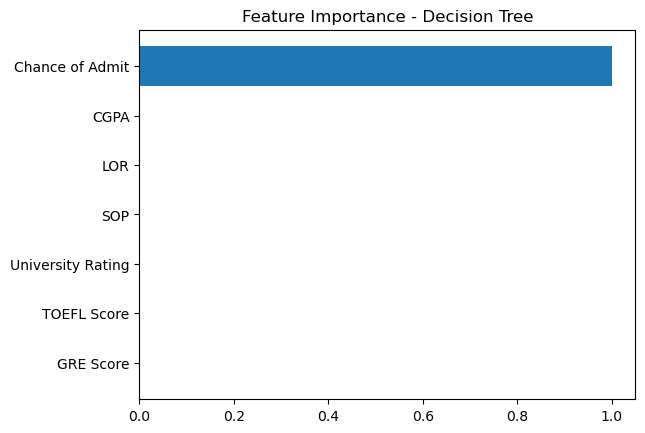

In [153]:
import matplotlib.pyplot as plt

plt.barh(X_train.columns, tree_model.feature_importances_)
plt.title('Feature Importance - Decision Tree')
plt.show()

In [154]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)


print(forest_model.feature_importances_)

[0.14230047 0.0522236  0.03819211 0.01340518 0.0156837  0.14641017
 0.59178478]


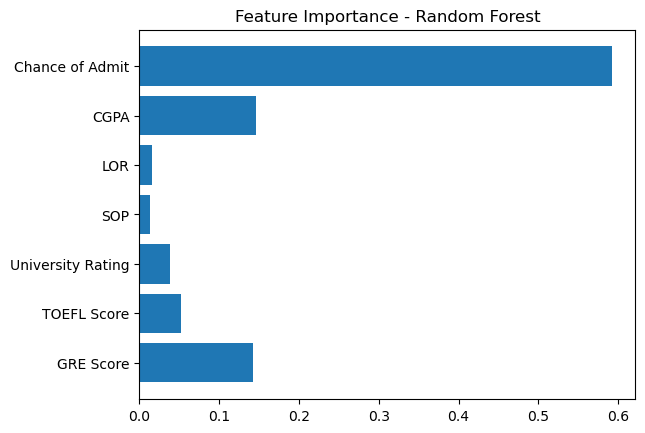

In [155]:
plt.barh(X_train.columns, forest_model.feature_importances_)
plt.title('Feature Importance - Random Forest')
plt.show()

### Exercises:
- Computing feature importance with decision trees

In [156]:
heart = pd.read_csv('heart.csv')
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [157]:
from matplotlib.pyplot import axis
X = heart.drop('target', axis=1)
y = heart['target']

In [160]:
y.value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [161]:
X.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
38   1    2   138       175   0    1        173      0      0.0      2      4   2       8
40   1    0   152       223   0    1        181      0      0.0      2      0   3       4
              110       167   0    0        114      1      2.0      1      0   3       4
41   1    1   120       157   0    1        182      0      0.0      2      0   2       4
71   0    0   112       149   0    1        125      0      1.6      1      0   2       4
                                                                                       ..
41   0    1   105       198   0    1        168      0      0.0      2      1   2       3
40   1    3   140       199   0    1        178      1      1.4      2      0   3       3
34   0    1   118       210   0    1        192      0      0.7      2      0   2       3
77   1    0   125       304   0    0        162      1      0.0      2      3   2       3
39   1    2   1

In [162]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


### Computing feature importance with random forests

In [166]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Derive feature importances
feature_importances = model.feature_importances_

# Plot the feature importances
plt.bar(X_train.columns, feature_importances)
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [820, 205]